# NORMALISASI MIN-MAX #

In [19]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ==============================================================================
# DATA
# ==============================================================================
df_minmax = pd.read_csv('dataset_fasilitas_kesehatan_skripsi_kedua.csv')
kolom_string = [
    'kode_provinsi',
    'kode_kabupaten_kota',
]

df_minmax[kolom_string] = df_minmax[kolom_string].astype(str)

kolom_numerik = [
    col for col in df_minmax.select_dtypes(include='number').columns
    if col != 'tahun'
]

print("=========== DATA ===========")
df_minmax

=========== DATA ===========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,9,15,347,141,619,41173,292,592938
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,12,19,519,129,990,46778,479,962125
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,3,19,384,227,792,40464,285,748432
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,14,18,609,263,1098,114929,507,1109547
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,6,18,540,233,837,65232,392,1230159
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,8,0,1,0,261,18844,287,213469
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,6,0,4,0,396,16010,129,142272
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,6,0,5,0,521,23764,756,201733
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,40,23,69,0,7446,851331,2299,3018022


In [20]:
# ==============================================================================
# STANDARDISASI MIN-MAX
# ==============================================================================
scaler = MinMaxScaler()

df_minmax[kolom_numerik] = scaler.fit_transform(df_minmax[kolom_numerik])

print("========== HASIL STANDARDISASI MIN-MAX ==========")
df_minmax

========== HASIL STANDARDISASI MIN-MAX ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.219512,0.348837,0.167795,0.026609,0.037795,0.047024,0.003308,0.157688
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.292683,0.441860,0.250967,0.024344,0.070104,0.053427,0.005678,0.285919
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,0.073171,0.441860,0.185687,0.042838,0.052861,0.046214,0.003219,0.211696
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.341463,0.418605,0.294487,0.049632,0.079509,0.131278,0.006033,0.337123
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.146341,0.418605,0.261122,0.043971,0.056780,0.074507,0.004575,0.379016
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.195122,0.000000,0.000484,0.000000,0.006618,0.021517,0.003244,0.025885
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.146341,0.000000,0.001934,0.000000,0.018375,0.018280,0.001242,0.001156
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.146341,0.000000,0.002418,0.000000,0.029261,0.027137,0.009188,0.021809
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,0.975610,0.534884,0.033366,0.000000,0.632326,0.972493,0.028744,1.000000


* K-MEANS CLUSTERING


In [21]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [22]:
#===============================================================================
# DATA
#===============================================================================

df_minmax_kmeans = df_minmax.copy()
df_minmax_kmeans

,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.219512,0.348837,0.167795,0.026609,0.037795,0.047024,0.003308,0.157688
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.292683,0.441860,0.250967,0.024344,0.070104,0.053427,0.005678,0.285919
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,0.073171,0.441860,0.185687,0.042838,0.052861,0.046214,0.003219,0.211696
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.341463,0.418605,0.294487,0.049632,0.079509,0.131278,0.006033,0.337123
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.146341,0.418605,0.261122,0.043971,0.056780,0.074507,0.004575,0.379016
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.195122,0.000000,0.000484,0.000000,0.006618,0.021517,0.003244,0.025885
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.146341,0.000000,0.001934,0.000000,0.018375,0.018280,0.001242,0.001156
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.146341,0.000000,0.002418,0.000000,0.029261,0.027137,0.009188,0.021809
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,0.975610,0.534884,0.033366,0.000000,0.632326,0.972493,0.028744,1.000000


========== ELBOW METHOD ==========


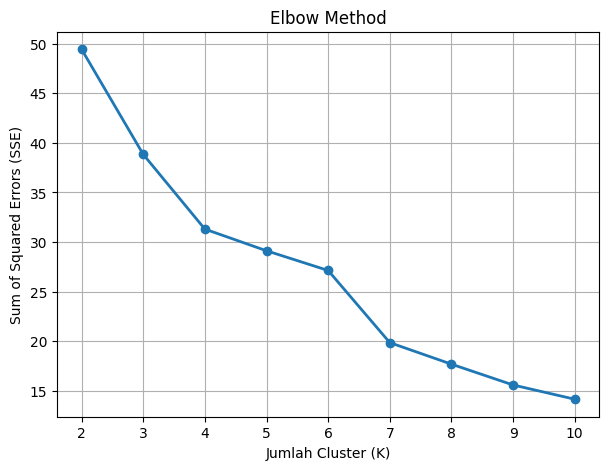

In [23]:
#===============================================================================
# 1. TENTUKAN JUMLAH CLUSTER (K)
#===============================================================================

# --------------------------
# 1.1. ELBOW METHOD
# --------------------------

print("========== ELBOW METHOD ==========")

sse = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42
    )
    kmeans.fit(df_minmax_kmeans[kolom_numerik])
    sse.append(kmeans.inertia_)
    
plt.figure(figsize=(7,5))
plt.plot(
    K,
    sse,
    marker='o',
    linewidth=2
)

plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.xticks(K)
plt.grid(True)

plt.show()

In [24]:
# --------------------------
# 1.2. SILHOUETTE SCORE, DAVIES-BOULDIN INDEX, CALINSKI-HARABASZ INDEX
# --------------------------

hasil_evaluasi = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42
    )

    cluster = kmeans.fit_predict(df_minmax_kmeans[kolom_numerik])

    silhouette = silhouette_score(df_minmax_kmeans[kolom_numerik], cluster)
    dbi = davies_bouldin_score(df_minmax_kmeans[kolom_numerik], cluster)
    chi = calinski_harabasz_score(df_minmax_kmeans[kolom_numerik], cluster)

    hasil_evaluasi.append({
        'Jumlah Cluster (K)': k,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': dbi,
        'Calinski-Harabasz Index': chi
    })

hasil_evaluasi = pd.DataFrame(hasil_evaluasi)

print("========== HASIL EVALUASI JUMLAH CLUSTER==========")
display(hasil_evaluasi.round(4))

========== HASIL EVALUASI JUMLAH CLUSTER==========


,Jumlah Cluster (K),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,2,0.3436,1.3555,112.7836
1,3,0.3011,1.2181,107.4485
2,4,0.2997,1.1694,109.5965
3,5,0.3022,1.0444,92.9340
4,6,0.2556,1.2978,83.3047
5,7,0.3613,1.0306,110.3722
6,8,0.3144,1.0854,110.3681
7,9,0.3329,1.0305,113.5031
8,10,0.3404,1.0319,113.6159


In [25]:
# --------------------------
# 1.3. K OPTIMAL
# --------------------------

print("========== K OPTIMAL ==========")


k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Silhouette Score'].idxmax(), 'Jumlah Cluster (K)']
print("1. K Optimal berdasarkan Silhouette Score:", k_optimal)


========== K OPTIMAL ==========
1. K Optimal berdasarkan Silhouette Score: 7


In [26]:
k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Davies-Bouldin Index'].idxmin(), 'Jumlah Cluster (K)']
print("2. K Optimal berdasarkan Davies-Bouldin Index:", k_optimal)

2. K Optimal berdasarkan Davies-Bouldin Index: 9


In [27]:
k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Calinski-Harabasz Index'].idxmax(), 'Jumlah Cluster (K)']
print("3. K Optimal berdasarkan Calinski-Harabasz Index:", k_optimal)

3. K Optimal berdasarkan Calinski-Harabasz Index: 10


_KLASTER OPTIMAL YANG DIGUNAKAN_

In [28]:
k = 7

In [29]:
#===============================================================================
# 2. PROSES K-MEANS CLUSTERING
#===============================================================================

# --------------------------
# 2.1. INISIALISASI MODEL & PARAMETER K-MEANS
# --------------------------
kmeans = KMeans(
    n_clusters=k,
    init='k-means++',
    random_state=42
)

# --------------------------
# 2.2. FIT MODEL K-MEANS
# --------------------------
kmeans.fit(df_minmax_kmeans[kolom_numerik])


#--------------------------
# 2.3. SIMPAN CENTROID
#--------------------------
centroid = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=kolom_numerik
)

centroid.insert(0, "Cluster", range(1, len(centroid) + 1))

print("========== CENTROID ==========")
display(centroid)



========== CENTROID ==========


,Cluster,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,1,0.067542,0.795170,0.521109,0.042947,0.158401,0.262937,0.045993,0.594510
1,2,0.102539,0.044613,0.101932,0.020562,0.046479,0.034213,0.014846,0.024596
2,3,0.469871,0.385089,0.535115,0.058058,0.162296,0.288164,0.060069,0.535503
3,4,1.000000,0.511628,0.971470,0.894886,0.903161,0.392125,0.815222,0.986588
4,5,0.995122,0.516279,0.595455,0.104397,0.698232,0.808831,0.074426,0.984305
5,6,0.473962,0.208674,0.263291,0.049265,0.108673,0.104202,0.035875,0.353464
6,7,0.128211,0.456884,0.269458,0.021919,0.066648,0.141856,0.026126,0.286962


In [30]:
# ---------------------------
# 2.4. SIMPAN LABEL CLUSTER
# ---------------------------

print("========== LABEL CLUSTER ==========")
df_minmax_kmeans['cluster_kmeans'] = kmeans.fit_predict(df_minmax_kmeans[kolom_numerik])
df_minmax_kmeans["cluster_kmeans"] = kmeans.labels_ + 1
df_minmax_kmeans

========== LABEL CLUSTER ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster_kmeans
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.219512,0.348837,0.167795,0.026609,0.037795,0.047024,0.003308,0.157688,7
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.292683,0.441860,0.250967,0.024344,0.070104,0.053427,0.005678,0.285919,7
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,0.073171,0.441860,0.185687,0.042838,0.052861,0.046214,0.003219,0.211696,7
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.341463,0.418605,0.294487,0.049632,0.079509,0.131278,0.006033,0.337123,7
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.146341,0.418605,0.261122,0.043971,0.056780,0.074507,0.004575,0.379016,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.195122,0.000000,0.000484,0.000000,0.006618,0.021517,0.003244,0.025885,2
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.146341,0.000000,0.001934,0.000000,0.018375,0.018280,0.001242,0.001156,2
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.146341,0.000000,0.002418,0.000000,0.029261,0.027137,0.009188,0.021809,2
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,0.975610,0.534884,0.033366,0.000000,0.632326,0.972493,0.028744,1.000000,5


In [31]:
#===============================================================================
# 2.5. SIMPAN HASIL CLUSTERING K-MEANS (DATA ASLI)
#===============================================================================
df_hasil = pd.read_csv('dataset_baru.csv').copy()

df_hasil["cluster_kmeans"] = kmeans.labels_ + 1

print("========== HASIL CLUSTERING K-MEANS ==========")
display(df_hasil)

========== HASIL CLUSTERING K-MEANS ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster_kmeans
0,35,JAWA TIMUR,3501,PACITAN,2018,9,15,347,141,619,41173,292,592938,7
1,35,JAWA TIMUR,3502,PONOROGO,2018,12,19,519,129,990,46778,479,962125,7
2,35,JAWA TIMUR,3503,TRENGGALEK,2018,3,19,384,227,792,40464,285,748432,7
3,35,JAWA TIMUR,3504,TULUNGAGUNG,2018,14,18,609,263,1098,114929,507,1109547,7
4,35,JAWA TIMUR,3505,BLITAR,2018,6,18,540,233,837,65232,392,1230159,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,8,0,1,0,261,18844,287,213469,2
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,6,0,4,0,396,16010,129,142272,2
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,6,0,5,0,521,23764,756,201733,2
264,35,JAWA TIMUR,3578,SURABAYA,2024,40,23,69,0,7446,851331,2299,3018022,5


In [32]:
# ---------------------------
# JUMLAH ANGGOTA CLUSTER
# ---------------------------

jumlah_cluster = (
    df_hasil["cluster_kmeans"]
    .value_counts()
    .sort_index()
)

display(jumlah_cluster)

cluster_kmeans
1     26
2     49
3     34
4      2
5      5
6     37
7    113
Name: count, dtype: int64

In [33]:
#===============================================================================
# 3. EVALUASI HASIL CLUSTERING K-MEANS
#===============================================================================

silhouette = silhouette_score(
    df_minmax_kmeans[kolom_numerik],
    df_minmax_kmeans['cluster_kmeans']
)

dbi = davies_bouldin_score(
    df_minmax_kmeans[kolom_numerik],
    df_minmax_kmeans['cluster_kmeans']
)

chi = calinski_harabasz_score(
    df_minmax_kmeans[kolom_numerik],
    df_minmax_kmeans['cluster_kmeans']
)

print("========== HASIL EVALUASI K-MEANS ==========")
print(f"Silhouette Score        : {silhouette:.4f}")
print(f"Davies-Bouldin Index    : {dbi:.4f}")
print(f"Calinski-Harabasz Index : {chi:.4f}")

========== HASIL EVALUASI K-MEANS ==========
Silhouette Score        : 0.3613
Davies-Bouldin Index    : 1.0306
Calinski-Harabasz Index : 110.3722


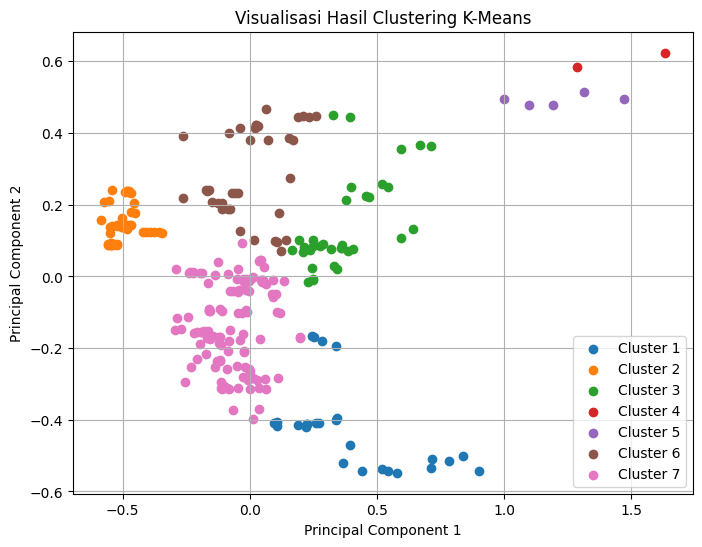

In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_minmax_kmeans[kolom_numerik])

df_pca = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
df_pca["Cluster"] = kmeans.labels_ + 1

plt.figure(figsize=(8,6))

for cluster in sorted(df_pca["Cluster"].unique()):
    subset = df_pca[df_pca["Cluster"] == cluster]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}"
    )

plt.title("Visualisasi Hasil Clustering K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()